# Tennis Stroke Classifier -- 1D-CNN (separate notebook, separate kernel)

**Why a separate file from `tennis-pose-classifier.ipynb`:** that notebook already
imports `xgboost`, which pulls in Homebrew's `libomp`. PyTorch bundles its own,
separate copy of OpenMP. Both loaded in the *same process* deadlock silently on
macOS the moment torch does real tensor work -- confirmed by hours of debugging
this exact hang. A separate notebook means a separate kernel means torch is the
only thing touching OpenMP here. Root cause avoided, not just patched around.

## Engineering Skill Targets
*(see ML_AVIATION_JOURNEY.md -> Running Practices -> README skill-check)*

1. **Problem framing** -- same as the tabular notebook: predict stroke
   (`backhand`/`flat_service`/`forehand_flat`/`smash`) from a clip, but here
   the input is the *full ordered sequence* of per-frame signals instead of
   phase-aggregated summary stats.
2. **Data understanding** -- reuses the same `clip_to_frames` /
   `compute_raw_signals` logic already validated in the other notebook
   (visually confirmed against the annotated video earlier).
3. **Evaluation rigor** -- same subject-based (`actor`) group split, same
   multi-seed check pattern, so results are directly comparable to the
   tabular models' numbers.
4. **Under-the-hood understanding** -- this is the one model in the whole
   project actually trained by hand: architecture, forward pass, loss,
   backprop all explicit below, not a black-box `.fit()` call.
5. **Build vs. use** -- everything here is ours: the resampling design, the
   architecture choice (flatten instead of global-pool, to keep temporal
   position -- see the CNN-vs-LSTM discussion), the training loop.
6. **Integration** -- this model's result feeds back into the comparison
   started in `tennis-pose-classifier.ipynb`: does keeping full frame order
   fix the serve/smash confusion the tabular models couldn't?

## Design recap
- Each clip's raw per-frame signals resampled to a fixed 64 timesteps
  (interpolation), so clips of different original lengths are comparable.
- Architecture **deliberately avoids global pooling** -- flattens the conv
  output while keeping the time axis, so *where* a pattern fired isn't
  thrown away. That's the fix for the CNN limitation from our discussion:
  a global-pooled CNN can't tell "toss then swing" from "swing then toss."
- Per-channel standardization fit on train data only, no test-set leakage.
- Plain `print(..., flush=True)` logging at every checkpoint, not `tqdm` --
  learned the hard way that widget-based progress bars can fail to render
  silently and look identical to a real hang.

In [1]:
# Defensive threading flags -- cheap insurance even though the root cause
# (xgboost's libomp + torch's bundled OpenMP in one process) shouldn't apply
# here since this kernel never imports xgboost.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:
import math
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

torch.set_num_threads(1)

# Smoke test -- confirms torch actually works in this kernel before we build
# anything on top of it. Should print instantly.
print(torch.tensor([1.0, 2.0, 3.0]))

tensor([1., 2., 3.])


## 1. Load keypoints (same file the other notebook uses)

In [24]:
df = pd.read_parquet("keypoints.parquet")
print(f"{len(df)} keypoint rows, {df['clip_id'].nunique()} clips, "
      f"{df['actor'].nunique()} subjects, classes: {sorted(df['action'].unique())}")

4807440 keypoint rows, 1980 clips, 55 subjects, classes: ['backhand', 'backhand2hands', 'backhand_slice', 'backhand_volley', 'flat_service', 'forehand_flat', 'forehand_openstands', 'forehand_slice', 'forehand_volley', 'kick_service', 'slice_service', 'smash']


## 2. Per-frame signals (same design as the tabular notebook, no phase-aggregation this time)

In [25]:
LEFT_SHOULDER, RIGHT_SHOULDER = 11, 12
LEFT_ELBOW, RIGHT_ELBOW = 13, 14
LEFT_WRIST, RIGHT_WRIST = 15, 16
LEFT_HIP, RIGHT_HIP = 23, 24
LEFT_KNEE, RIGHT_KNEE = 25, 26
LEFT_ANKLE, RIGHT_ANKLE = 27, 28

MIN_VISIBILITY = 0.5
SEQ_LEN = 64


def _get(frame, landmark_id, min_visibility):
    row = frame.get(landmark_id)
    if row is None or row["visibility"] < min_visibility:
        return None
    return row["x"], row["y"]


def _angle(a, b, c):
    if a is None or b is None or c is None:
        return np.nan
    v1 = (a[0] - b[0], a[1] - b[1])
    v2 = (c[0] - b[0], c[1] - b[1])
    n1, n2 = math.hypot(*v1), math.hypot(*v2)
    if n1 == 0 or n2 == 0:
        return np.nan
    cos_angle = (v1[0] * v2[0] + v1[1] * v2[1]) / (n1 * n2)
    cos_angle = max(-1.0, min(1.0, cos_angle))
    return math.degrees(math.acos(cos_angle))


def _dist(a, b):
    if a is None or b is None:
        return np.nan
    return math.hypot(a[0] - b[0], a[1] - b[1])


def clip_to_frames(clip_df, min_visibility):
    frames = {}
    for frame_idx, group in clip_df.groupby("frame_idx"):
        frames[frame_idx] = {
            int(r.landmark_id): {"x": r.x, "y": r.y, "visibility": r.visibility}
            for r in group.itertuples()
        }
    return dict(sorted(frames.items()))


SIGNAL_COLUMNS = [
    "left_elbow_angle", "right_elbow_angle",
    "left_knee_angle", "right_knee_angle",
    "left_wrist_rel_height", "right_wrist_rel_height",
    "torso_rotation_deg",
    "left_wrist_speed", "right_wrist_speed",
]


def compute_raw_signals(frames, min_visibility):
    records = []
    prev_wrist = {"left": None, "right": None}
    prev_frame_idx = None

    for frame_idx, lm in frames.items():
        ls = _get(lm, LEFT_SHOULDER, min_visibility)
        rs = _get(lm, RIGHT_SHOULDER, min_visibility)
        le = _get(lm, LEFT_ELBOW, min_visibility)
        re = _get(lm, RIGHT_ELBOW, min_visibility)
        lw = _get(lm, LEFT_WRIST, min_visibility)
        rw = _get(lm, RIGHT_WRIST, min_visibility)
        lh = _get(lm, LEFT_HIP, min_visibility)
        rh = _get(lm, RIGHT_HIP, min_visibility)
        lk = _get(lm, LEFT_KNEE, min_visibility)
        rk = _get(lm, RIGHT_KNEE, min_visibility)
        la = _get(lm, LEFT_ANKLE, min_visibility)
        ra = _get(lm, RIGHT_ANKLE, min_visibility)

        shoulder_width = _dist(ls, rs)

        def speed(prev, cur):
            if prev is None or cur is None or not shoulder_width or np.isnan(shoulder_width):
                return np.nan
            gap = frame_idx - prev_frame_idx if prev_frame_idx is not None else 1
            gap = max(gap, 1)
            return _dist(prev, cur) / gap / shoulder_width

        rec = {
            "frame_idx": frame_idx,
            "left_elbow_angle": _angle(ls, le, lw),
            "right_elbow_angle": _angle(rs, re, rw),
            "left_knee_angle": _angle(lh, lk, la),
            "right_knee_angle": _angle(rh, rk, ra),
            "left_wrist_rel_height": (ls[1] - lw[1]) if ls and lw else np.nan,
            "right_wrist_rel_height": (rs[1] - rw[1]) if rs and rw else np.nan,
            "torso_rotation_deg": (
                math.degrees(math.atan2(rs[1] - ls[1], rs[0] - ls[0])) if ls and rs else np.nan
            ),
            "left_wrist_speed": speed(prev_wrist["left"], lw),
            "right_wrist_speed": speed(prev_wrist["right"], rw),
        }
        records.append(rec)
        prev_wrist = {"left": lw, "right": rw}
        prev_frame_idx = frame_idx

    return pd.DataFrame(records)

## 3. Resample to fixed length + build the sequence dataset

In [26]:
def resample_signals(signals_df, target_len=SEQ_LEN):
    n = len(signals_df)
    if n < 2:
        return None
    old_idx = np.linspace(0, 1, n)
    new_idx = np.linspace(0, 1, target_len)
    channels = []
    for col in SIGNAL_COLUMNS:
        s = signals_df[col].astype(float).interpolate(limit_direction="both")
        s = s.fillna(0.0)
        channels.append(np.interp(new_idx, old_idx, s.values))
    return np.stack(channels, axis=0)  # (n_channels, target_len)


def build_sequence_dataset(kp_df, min_visibility, target_len=SEQ_LEN):
    X_list, y_list, actor_list = [], [], []
    meta_cols = kp_df[["clip_id", "actor", "action"]].drop_duplicates("clip_id")
    meta_lookup = meta_cols.set_index("clip_id").to_dict("index")

    for clip_id, clip_df in kp_df.groupby("clip_id"):
        frames = clip_to_frames(clip_df, min_visibility)
        signals_df = compute_raw_signals(frames, min_visibility)
        seq = resample_signals(signals_df, target_len)
        if seq is None:
            continue
        meta = meta_lookup[clip_id]
        X_list.append(seq)
        y_list.append(meta["action"])
        actor_list.append(meta["actor"])

    return np.stack(X_list), np.array(y_list), np.array(actor_list)


print("Building sequence dataset (iterates all clips -- may take a little while, no progress bar, be patient briefly)...", flush=True)
X_seq, y_seq, groups_seq = build_sequence_dataset(df, MIN_VISIBILITY, target_len=SEQ_LEN)
print(f"X_seq shape: {X_seq.shape}  (clips, channels, timesteps)", flush=True)

encoder = LabelEncoder()
y_seq_encoded = encoder.fit_transform(y_seq)
print(f"classes: {list(encoder.classes_)}")

Building sequence dataset (iterates all clips -- may take a little while, no progress bar, be patient briefly)...
X_seq shape: (1980, 9, 64)  (clips, channels, timesteps)
classes: [np.str_('backhand'), np.str_('backhand2hands'), np.str_('backhand_slice'), np.str_('backhand_volley'), np.str_('flat_service'), np.str_('forehand_flat'), np.str_('forehand_openstands'), np.str_('forehand_slice'), np.str_('forehand_volley'), np.str_('kick_service'), np.str_('slice_service'), np.str_('smash')]


## 4. Model

In [27]:
class StrokeCNN(nn.Module):
    """
    Two conv layers + moderate (not global) pooling -- flatten keeps a
    notion of early/mid/late position instead of collapsing it away, which
    is the whole point (see CNN-vs-LSTM discussion in the project journal).
    """
    def __init__(self, n_channels, seq_len, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        reduced_len = seq_len // 4
        self.fc1 = nn.Linear(64 * reduced_len, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

## 5. Train + evaluate, 3 seeds, plain-print progress at every checkpoint

In [28]:
def train_and_eval_cnn(X_train, y_train, X_test, y_test, n_classes, epochs=60, lr=1e-3, seed=0):
    print("    building model...", flush=True)
    torch.manual_seed(seed)
    model = StrokeCNN(X_train.shape[1], X_train.shape[2], n_classes)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    print("    converting data to tensors...", flush=True)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    print(f"    tensors ready ({X_train_t.shape[0]} train, {X_test_t.shape[0]} test) -- starting {epochs} epochs", flush=True)
    epoch_start = time.time()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        opt.step()
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"    epoch {epoch+1}/{epochs}  loss={loss.item():.4f}  ({time.time()-epoch_start:.1f}s elapsed)", flush=True)

    print("    training done, evaluating on test set...", flush=True)
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1).numpy()
    print("    done.", flush=True)
    return preds, model


def run_cnn_split(X_seq, y_encoded, groups, seed):
    print(f"  splitting data for seed {seed}...", flush=True)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_seq, y_encoded, groups))
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    print(f"  split done: {len(train_idx)} train, {len(test_idx)} test. standardizing...", flush=True)

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    print("  calling train_and_eval_cnn...", flush=True)
    preds, model = train_and_eval_cnn(X_train, y_train, X_test, y_test,
                                       n_classes=len(encoder.classes_), seed=seed)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    return acc, f1, (y_test, preds)

In [29]:
cnn_accs, cnn_f1s = [], []
last_cnn_result = None
overall_start = time.time()

for seed in range(3):
    print(f"=== seed {seed} starting ===", flush=True)
    seed_start = time.time()
    acc, f1, result = run_cnn_split(X_seq, y_seq_encoded, groups_seq, seed)
    cnn_accs.append(acc)
    cnn_f1s.append(f1)
    last_cnn_result = result
    print(f"=== seed {seed} done: accuracy {acc:.3f}  macro-F1 {f1:.3f}  ({time.time()-seed_start:.1f}s) ===\n", flush=True)

print(f"Total time: {time.time() - overall_start:.1f}s")
cnn_accs, cnn_f1s = np.array(cnn_accs), np.array(cnn_f1s)
print(f"\n1D-CNN over {len(cnn_accs)} splits: accuracy {cnn_accs.mean():.3f} +/- {cnn_accs.std():.3f}"
      f"   macro-F1 {cnn_f1s.mean():.3f} +/- {cnn_f1s.std():.3f}")
print("\nCompare against tennis-pose-classifier.ipynb\'s tabular results:")
print("  logistic_regression  accuracy 0.663 +/- 0.041")
print("  random_forest        accuracy 0.662 +/- 0.048")
print("  xgboost               accuracy 0.671 +/- 0.023")

=== seed 0 starting ===
  splitting data for seed 0...
  split done: 1476 train, 504 test. standardizing...
  calling train_and_eval_cnn...
    building model...
    converting data to tensors...
    tensors ready (1476 train, 504 test) -- starting 60 epochs
    epoch 1/60  loss=2.4889  (0.3s elapsed)
    epoch 6/60  loss=2.3275  (1.5s elapsed)
    epoch 11/60  loss=2.0018  (2.8s elapsed)
    epoch 16/60  loss=1.6383  (4.1s elapsed)
    epoch 21/60  loss=1.4264  (5.4s elapsed)
    epoch 26/60  loss=1.3148  (6.7s elapsed)
    epoch 31/60  loss=1.2230  (8.0s elapsed)
    epoch 36/60  loss=1.1449  (9.3s elapsed)
    epoch 41/60  loss=1.0871  (10.6s elapsed)
    epoch 46/60  loss=1.0023  (11.9s elapsed)
    epoch 51/60  loss=0.9786  (13.2s elapsed)
    epoch 56/60  loss=0.9109  (14.5s elapsed)
    epoch 60/60  loss=0.8812  (15.5s elapsed)
    training done, evaluating on test set...
    done.
=== seed 0 done: accuracy 0.474  macro-F1 0.468  (15.6s) ===

=== seed 1 starting ===
  splitting 

## 6. Confusion matrix -- the real question: did serve/smash improve?

In [30]:
y_test_last, preds_last = last_cnn_result
print("Confusion matrix (1D-CNN, last split) -- rows=true, cols=predicted:")
display(pd.DataFrame(
    confusion_matrix(y_test_last, preds_last),
    index=encoder.classes_, columns=encoder.classes_,
))
print("\nFull classification report (1D-CNN, last split):")
print(classification_report(y_test_last, preds_last, target_names=encoder.classes_))
print("\nCompare against the random forest confusion matrix in tennis-pose-classifier.ipynb --")
print("specifically the smash/flat_service block (was 16 smash->flat_service, 11 flat_service->smash).")

Confusion matrix (1D-CNN, last split) -- rows=true, cols=predicted:


,backhand,backhand2hands,backhand_slice,backhand_volley,flat_service,forehand_flat,forehand_openstands,forehand_slice,forehand_volley,kick_service,slice_service,smash
backhand,29,0,3,3,0,2,1,2,2,0,0,0
backhand2hands,0,30,0,1,0,6,4,0,0,0,1,0
backhand_slice,6,3,21,9,0,0,0,2,1,0,0,0
backhand_volley,0,0,15,20,0,0,0,4,3,0,0,0
flat_service,1,1,0,1,18,0,3,0,0,11,6,1
forehand_flat,4,0,3,3,0,14,13,2,2,0,0,1
forehand_openstands,0,2,2,2,1,5,30,0,0,0,0,0
forehand_slice,3,0,4,3,0,3,2,9,17,0,1,0
forehand_volley,1,0,5,2,0,2,2,4,26,0,0,0
kick_service,0,0,1,1,17,0,1,0,0,13,7,2



Full classification report (1D-CNN, last split):
                     precision    recall  f1-score   support

           backhand       0.66      0.69      0.67        42
     backhand2hands       0.71      0.71      0.71        42
     backhand_slice       0.39      0.50      0.44        42
    backhand_volley       0.42      0.48      0.44        42
       flat_service       0.32      0.43      0.37        42
      forehand_flat       0.44      0.33      0.38        42
forehand_openstands       0.54      0.71      0.61        42
     forehand_slice       0.39      0.21      0.28        42
    forehand_volley       0.51      0.62      0.56        42
       kick_service       0.32      0.31      0.31        42
      slice_service       0.38      0.26      0.31        42
              smash       0.71      0.48      0.57        42

           accuracy                           0.48       504
          macro avg       0.48      0.48      0.47       504
       weighted avg       0.48   

In [10]:
# Rebuild with clip_id tracked this time, and verify it's identical to what we already trained on.
def build_sequence_dataset_with_ids(kp_df, min_visibility, target_len=SEQ_LEN):
    X_list, y_list, actor_list, clip_id_list = [], [], [], []
    meta_cols = kp_df[["clip_id", "actor", "action"]].drop_duplicates("clip_id")
    meta_lookup = meta_cols.set_index("clip_id").to_dict("index")

    for clip_id, clip_df in kp_df.groupby("clip_id"):
        frames = clip_to_frames(clip_df, min_visibility)
        signals_df = compute_raw_signals(frames, min_visibility)
        seq = resample_signals(signals_df, target_len)
        if seq is None:
            continue
        meta = meta_lookup[clip_id]
        X_list.append(seq)
        y_list.append(meta["action"])
        actor_list.append(meta["actor"])
        clip_id_list.append(clip_id)

    return np.stack(X_list), np.array(y_list), np.array(actor_list), np.array(clip_id_list)


X_check, y_check, groups_check, clip_ids_seq = build_sequence_dataset_with_ids(df, MIN_VISIBILITY, target_len=SEQ_LEN)
y_check_encoded = encoder.transform(y_check)
assert np.allclose(X_check, X_seq), "mismatch -- data changed since training"
print("Confirmed: same data, clip_id now tracked.")

Confirmed: same data, clip_id now tracked.


In [11]:
# Reconstruct the exact seed=2 split (the last one run in the loop) and match it to last_cnn_result.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=2)
train_idx, test_idx = next(splitter.split(X_seq, y_seq_encoded, groups_seq))
test_clip_ids = clip_ids_seq[test_idx]

y_test_last, preds_last = last_cnn_result
assert np.array_equal(y_seq_encoded[test_idx], y_test_last), "split mismatch"

smash_label = list(encoder.classes_).index("smash")
service_label = list(encoder.classes_).index("flat_service")
mask = (y_test_last == smash_label) & (preds_last == service_label)

print(f"{mask.sum()} clips: true smash, predicted flat_service")
for cid in test_clip_ids[mask]:
    print(" ", cid)

16 clips: true smash, predicted flat_service
  p10_smash_s2
  p19_smash_s1
  p19_smash_s2
  p19_smash_s3
  p21_smash_s3
  p34_smash_s1
  p35_smash_s3
  p39_smash_s1
  p39_smash_s3
  p45_smash_s1
  p45_smash_s3
  p47_smash_s2
  p47_smash_s3
  p48_smash_s2
  p51_smash_s3
  p6_smash_s2


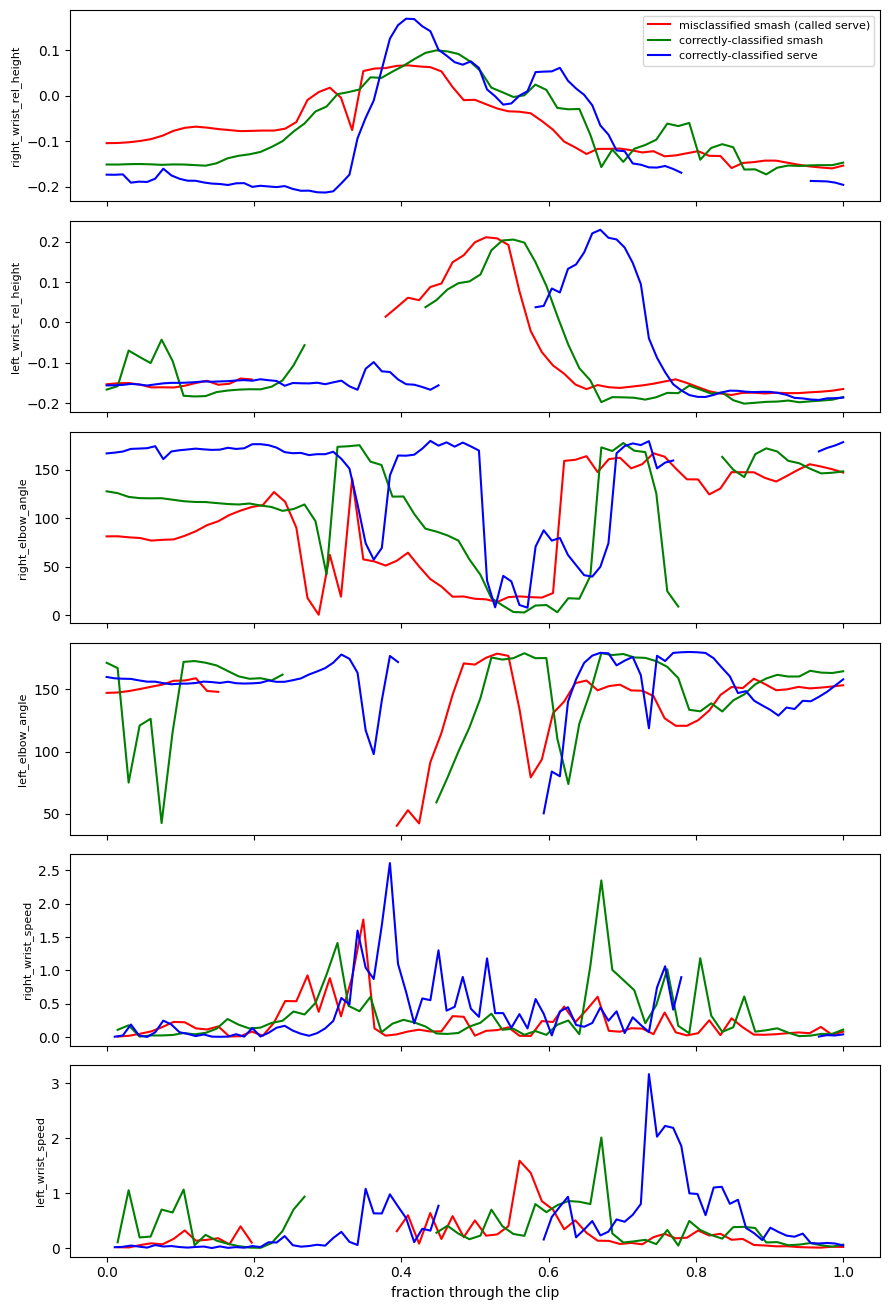

In [12]:
import matplotlib.pyplot as plt

def get_raw_signals_for_clip(kp_df, clip_id, min_visibility=MIN_VISIBILITY):
    clip_df = kp_df[kp_df["clip_id"] == clip_id]
    frames = clip_to_frames(clip_df, min_visibility)
    return compute_raw_signals(frames, min_visibility)


def plot_clip_comparison(kp_df, clip_ids_and_labels,
                          signals=("right_wrist_rel_height", "left_wrist_rel_height",
                                   "right_elbow_angle", "left_elbow_angle",
                                   "right_wrist_speed", "left_wrist_speed")):
    fig, axes = plt.subplots(len(signals), 1, figsize=(9, 2.2 * len(signals)), sharex=True)
    for clip_id, label, color in clip_ids_and_labels:
        sig_df = get_raw_signals_for_clip(kp_df, clip_id)
        x = np.linspace(0, 1, len(sig_df))  # fraction of clip, so different lengths align
        for ax, sig in zip(axes, signals):
            ax.plot(x, sig_df[sig], label=label, color=color)
    for ax, sig in zip(axes, signals):
        ax.set_ylabel(sig, fontsize=8)
    axes[0].legend(fontsize=8)
    axes[-1].set_xlabel("fraction through the clip")
    plt.tight_layout()
    plt.show()


# One misclassified smash, one correctly-classified smash, one correctly-classified serve
correct_smash_mask = (y_test_last == smash_label) & (preds_last == smash_label)
correct_service_mask = (y_test_last == service_label) & (preds_last == service_label)

plot_clip_comparison(df, [
    (test_clip_ids[mask][0], "misclassified smash (called serve)", "red"),
    (test_clip_ids[correct_smash_mask][0], "correctly-classified smash", "green"),
    (test_clip_ids[correct_service_mask][0], "correctly-classified serve", "blue"),
])

In [13]:
def run_cnn_split_with_model(X_seq, y_encoded, groups, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_seq, y_encoded, groups))
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std

    preds, model = train_and_eval_cnn(X_train_std, y_train, X_test_std, y_test,
                                       n_classes=len(encoder.classes_), seed=seed)
    return model, mean, std

model_s2, mean_s2, std_s2 = run_cnn_split_with_model(X_seq, y_seq_encoded, groups_seq, seed=2)

    building model...
    converting data to tensors...
    tensors ready (492 train, 168 test) -- starting 60 epochs
    epoch 1/60  loss=1.3905  (0.1s elapsed)
    epoch 6/60  loss=1.1942  (0.5s elapsed)
    epoch 11/60  loss=0.8696  (1.0s elapsed)
    epoch 16/60  loss=0.6304  (1.4s elapsed)
    epoch 21/60  loss=0.4814  (1.9s elapsed)
    epoch 26/60  loss=0.4063  (2.3s elapsed)
    epoch 31/60  loss=0.3569  (2.8s elapsed)
    epoch 36/60  loss=0.2782  (3.2s elapsed)
    epoch 41/60  loss=0.2654  (3.7s elapsed)
    epoch 46/60  loss=0.1964  (4.1s elapsed)
    epoch 51/60  loss=0.1818  (4.6s elapsed)
    epoch 56/60  loss=0.1523  (5.0s elapsed)
    epoch 60/60  loss=0.1277  (5.4s elapsed)
    training done, evaluating on test set...
    done.


In [17]:
def compute_saliency(model, x_raw, mean, std, target_class):
    x_std = (x_raw - mean[0]) / std[0]
    x_t = torch.tensor(x_std[None, :, :], dtype=torch.float32, requires_grad=True)
    model.eval()
    out = model(x_t)
    out[0, target_class].backward()
    return x_t.grad[0].abs().numpy()  # (channels, timesteps)

clip_id_to_check = "p18_serflat_s2"
idx = list(clip_ids_seq).index(clip_id_to_check)
x_raw = X_seq[idx]

service_label = list(encoder.classes_).index("flat_service")
saliency = compute_saliency(model_s2, x_raw, mean_s2, std_s2, service_label)

channel_importance = saliency.sum(axis=1)
print(f"Which of the 9 signals mattered most when the model called '{clip_id_to_check}' a serve:\n")
for ch, imp in sorted(zip(SIGNAL_COLUMNS, channel_importance), key=lambda x: -x[1]):
    print(f"  {ch:25s} {imp:.4f}")

Which of the 9 signals mattered most when the model called 'p18_serflat_s2' a serve:

  left_wrist_rel_height     4.2593
  right_elbow_angle         3.8839
  right_wrist_rel_height    3.1109
  left_elbow_angle          2.7812
  left_wrist_speed          2.7377
  torso_rotation_deg        2.4460
  right_knee_angle          2.3923
  right_wrist_speed         2.3642
  left_knee_angle           2.3427


In [18]:
def detect_dominant_hand(signals_df):
    """Whichever wrist reaches a higher peak speed during the clip is probably the swinging hand."""
    left_peak = signals_df["left_wrist_speed"].max()
    right_peak = signals_df["right_wrist_speed"].max()
    if pd.isna(left_peak) and pd.isna(right_peak):
        return None
    if pd.isna(left_peak):
        return "right"
    if pd.isna(right_peak):
        return "left"
    return "left" if left_peak > right_peak else "right"


# Validate against the 4 clips where you already know the true hand from watching the video.
known_handedness = {
    "p10_smash_s2": "left",
    "p19_smash_s3": "right",
    "p10_serflat_s2": "left",
    "p18_serflat_s2": "right",
}

for clip_id, true_hand in known_handedness.items():
    clip_df = df[df["clip_id"] == clip_id]
    frames = clip_to_frames(clip_df, MIN_VISIBILITY)
    signals_df = compute_raw_signals(frames, MIN_VISIBILITY)
    detected = detect_dominant_hand(signals_df)
    match = "correct" if detected == true_hand else "WRONG"
    print(f"{clip_id}: true={true_hand}  detected={detected}  -> {match}")

p10_smash_s2: true=left  detected=right  -> WRONG
p19_smash_s3: true=right  detected=right  -> correct
p10_serflat_s2: true=left  detected=right  -> WRONG
p18_serflat_s2: true=right  detected=left  -> WRONG


In [19]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.1 MB/s  0:00:003.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.6/837.6 kB 4.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 6.9 MB/s  0:00:06 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ultralytics] 4/5 [ultralytics]me-32]


In [21]:
from ultralytics import YOLO
import cv2
yolo = YOLO("yolov8n.pt")  # downloads automatically on first use, ~6MB, pretrained on COCO
RACKET_CLASS_NAME = "tennis racket"  # a real COCO class -- no training needed

def detect_dominant_hand_yolo(video_path, kp_df, clip_id, min_visibility=MIN_VISIBILITY):
    clip_df = kp_df[kp_df["clip_id"] == clip_id]
    frames = clip_to_frames(clip_df, min_visibility)

    cap = cv2.VideoCapture(video_path)
    votes = {"left": 0, "right": 0}
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx in frames:
            h, w = frame.shape[:2]
            results = yolo(frame, verbose=False)[0]
            racket_boxes = [b for b in results.boxes if yolo.names[int(b.cls)] == RACKET_CLASS_NAME]
            if racket_boxes:
                best = max(racket_boxes, key=lambda b: float(b.conf))
                x1, y1, x2, y2 = best.xyxy[0].tolist()
                racket_center = ((x1 + x2) / 2 / w, (y1 + y2) / 2 / h)  # normalize to match pose coords

                lw = _get(frames[frame_idx], LEFT_WRIST, min_visibility)
                rw = _get(frames[frame_idx], RIGHT_WRIST, min_visibility)
                if lw and rw:
                    if _dist(racket_center, lw) < _dist(racket_center, rw):
                        votes["left"] += 1
                    else:
                        votes["right"] += 1
        frame_idx += 1
    cap.release()

    if votes["left"] == 0 and votes["right"] == 0:
        return None, votes
    return ("left" if votes["left"] > votes["right"] else "right"), votes


# Same 4 known clips as before
known_handedness = {
    "p10_smash_s2": ("left", "data/thetis/VIDEO_RGB/smash/p10_smash_s2.avi"),
    "p19_smash_s3": ("right", "data/thetis/VIDEO_RGB/smash/p19_smash_s3.avi"),
    "p10_serflat_s2": ("left", "data/thetis/VIDEO_RGB/flat_service/p10_serflat_s2.avi"),
    "p18_serflat_s2": ("right", "data/thetis/VIDEO_RGB/flat_service/p18_serflat_s2.avi"),
}

for clip_id, (true_hand, video_path) in known_handedness.items():
    detected, votes = detect_dominant_hand_yolo(video_path, df, clip_id)
    match = "correct" if detected == true_hand else "WRONG"
    print(f"{clip_id}: true={true_hand}  detected={detected}  votes={votes}  -> {match}")

p10_smash_s2: true=left  detected=left  votes={'left': 20, 'right': 7}  -> correct
p19_smash_s3: true=right  detected=left  votes={'left': 18, 'right': 16}  -> WRONG
p10_serflat_s2: true=left  detected=right  votes={'left': 9, 'right': 12}  -> WRONG
p18_serflat_s2: true=right  detected=right  votes={'left': 4, 'right': 19}  -> correct


In [22]:
!bash download_thetis.sh

Existing clone found — adding classes to it.
remote: Enumerating objects: 1315, done.
remote: Total 1315 (delta 0), reused 0 (delta 0), pack-reused 1315 (from 1)
Receiving objects: 100% (1315/1315), 2.39 GiB | 17.93 MiB/s, done.
Updating files: 100% (1320/1320), done.
Done. Classes and clip counts:
  backhand_slice:      165
  backhand_volley:      165
  backhand:      165
  backhand2hands:      165
  flat_service:      165
  forehand_flat:      165
  forehand_openstands:      165
  forehand_slice:      165
  forehand_volley:      165
  kick_service:      165
  slice_service:      165
  smash:      165
Total:
    1980


In [23]:
!python extract_keypoints.py --video-dir data/thetis/VIDEO_RGB --out keypoints.parquet --resume

Found 12 action classes: ['backhand', 'backhand2hands', 'backhand_slice', 'backhand_volley', 'flat_service', 'forehand_flat', 'forehand_openstands', 'forehand_slice', 'forehand_volley', 'kick_service', 'slice_service', 'smash']
Resuming — 660 clips already done.
backhand2hands:   0%|                                  | 0/165 [00:00<?, ?it/s]I0000 00:00:1784008088.480686 28659595 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 15, prefix = pthread-default
I0000 00:00:1784008088.530566 28659595 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784008088.586243 28659599 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784008088.593030 28659605 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support f

## 7. LSTM -- respects frame order structurally, not as a workaround

The CNN's temporal-position fix (section 4 above) was a deliberate design
choice: skip global pooling so the flatten step keeps *some* notion of when
in the clip a pattern fired. That's a workaround -- a plain CNN over a fixed
window has no built-in sense of order, only positions in a fixed-size
intermediate tensor.

An LSTM is a structurally different fit: it processes the sequence one frame
at a time, carrying a hidden state forward, so "this happened before that" is
baked into how the model computes at all, not recovered after the fact from a
flattened tensor. Whether that structural fit actually wins on ~1980 short
clips is the empirical question this section answers -- not assumed.

**Design, kept as close to the CNN section as possible so this is a
one-variable-at-a-time comparison:**
- Same input: reuses `X_seq` / `y_seq_encoded` / `groups_seq` already built in
  section 3 -- same 9 raw per-frame signals, same 64-timestep resampling, no
  new preprocessing variable introduced.
- Same subject-based `GroupShuffleSplit`, same 3-seed rigor pattern, same
  per-channel standardization fit on train only.
- `nn.LSTM(input_size=9, hidden_size=64, batch_first=True)`, single layer --
  hidden size matched to the CNN's `fc1` width (64) rather than hand-tuned,
  so this compares *architecture*, not which model got more capacity.
- Classification reads the hidden state at the **last timestep** (all clips
  already resampled to a fixed 64 steps) through dropout + linear head -- the
  LSTM analogue of the CNN's "flatten, don't pool" choice: nothing gets
  averaged away, one specific temporal position carries the classification.
- `nn.LSTM` expects `(batch, seq_len, channels)`; `X_seq` is
  `(clips, channels, seq_len)` from the CNN section, so this section
  transposes it -- the only real difference in the input pipeline versus
  the CNN.

**Caveat carried over from section 5:** the tabular 0.66-0.67% numbers
printed there are the *4-class* problem (25% random baseline), not directly
comparable to a 12-class result (8.3% random baseline). The number to judge
the LSTM against is the CNN's 46.8% +/- 1.2% printed above -- same data, same
split logic, same class count. That's the real comparison.

In [ ]:
class StrokeLSTM(nn.Module):
    """
    Single-layer LSTM over the raw frame sequence. Order is structural here --
    the hidden state updates one frame at a time -- not recovered from a
    flattened tensor the way the CNN's design has to. Classification reads
    off the hidden state at the final timestep, then dropout + linear head,
    the direct analogue of the CNN's "flatten, don't global-pool" choice.
    """
    def __init__(self, n_channels, hidden_size, n_classes, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        # x: (batch, seq_len, channels)
        out, (h_n, c_n) = self.lstm(x)
        last_step = out[:, -1, :]     # hidden state at the final real timestep
        last_step = self.dropout(last_step)
        return self.fc(last_step)

In [ ]:
def train_and_eval_lstm(X_train, y_train, X_test, y_test, n_classes,
                         epochs=60, lr=1e-3, seed=0, hidden_size=64):
    print("    building model...", flush=True)
    torch.manual_seed(seed)
    model = StrokeLSTM(X_train.shape[2], hidden_size, n_classes)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    print("    converting data to tensors...", flush=True)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    print(f"    tensors ready ({X_train_t.shape[0]} train, {X_test_t.shape[0]} test) -- starting {epochs} epochs", flush=True)
    epoch_start = time.time()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        opt.step()
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"    epoch {epoch+1}/{epochs}  loss={loss.item():.4f}  ({time.time()-epoch_start:.1f}s elapsed)", flush=True)

    print("    training done, evaluating on test set...", flush=True)
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1).numpy()
    print("    done.", flush=True)
    return preds, model


def run_lstm_split(X_seq, y_encoded, groups, seed):
    print(f"  splitting data for seed {seed}...", flush=True)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_seq, y_encoded, groups))
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    print(f"  split done: {len(train_idx)} train, {len(test_idx)} test. standardizing...", flush=True)

    # standardize per channel in the CNN's (clips, channels, timesteps) layout,
    # then transpose to (clips, timesteps, channels) for nn.LSTM's batch_first input
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std
    X_train = X_train.transpose(0, 2, 1)  # (clips, timesteps, channels)
    X_test = X_test.transpose(0, 2, 1)

    print("  calling train_and_eval_lstm...", flush=True)
    preds, model = train_and_eval_lstm(X_train, y_train, X_test, y_test,
                                        n_classes=len(encoder.classes_), seed=seed)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    return acc, f1, (y_test, preds)

In [ ]:
lstm_accs, lstm_f1s = [], []
last_lstm_result = None
overall_start = time.time()

for seed in range(3):
    print(f"=== seed {seed} starting ===", flush=True)
    seed_start = time.time()
    acc, f1, result = run_lstm_split(X_seq, y_seq_encoded, groups_seq, seed)
    lstm_accs.append(acc)
    lstm_f1s.append(f1)
    last_lstm_result = result
    print(f"=== seed {seed} done: accuracy {acc:.3f}  macro-F1 {f1:.3f}  ({time.time()-seed_start:.1f}s) ===\n", flush=True)

print(f"Total time: {time.time() - overall_start:.1f}s")
lstm_accs, lstm_f1s = np.array(lstm_accs), np.array(lstm_f1s)
print(f"\nLSTM over {len(lstm_accs)} splits: accuracy {lstm_accs.mean():.3f} +/- {lstm_accs.std():.3f}"
      f"   macro-F1 {lstm_f1s.mean():.3f} +/- {lstm_f1s.std():.3f}")
print("\nCompare against the 1D-CNN on the SAME 12-class problem, same data, same split logic:")
print(f"  1D-CNN   accuracy {cnn_accs.mean():.3f} +/- {cnn_accs.std():.3f}   macro-F1 {cnn_f1s.mean():.3f} +/- {cnn_f1s.std():.3f}")
print("(the tabular 0.66-0.67 numbers printed in section 5 are the 4-class problem -- not a fair comparison point here)")

## 8. LSTM confusion matrix -- same three questions as the CNN

Checked directly against section 6's findings: did the smash/flat_service
confusion, the serve-trio confusion, and the forehand slice/volley confusion
move at all when the model respects frame order structurally instead of via
the CNN's flatten workaround?

In [ ]:
y_test_last, preds_last = last_lstm_result
print("Confusion matrix (LSTM, last split) -- rows=true, cols=predicted:")
display(pd.DataFrame(
    confusion_matrix(y_test_last, preds_last),
    index=encoder.classes_, columns=encoder.classes_,
))
print("\nFull classification report (LSTM, last split):")
print(classification_report(y_test_last, preds_last, target_names=encoder.classes_))

print("\nSpecific confusions to check against the CNN's results in section 6:")
smash_i = list(encoder.classes_).index("smash")
flat_i = list(encoder.classes_).index("flat_service")
kick_i = list(encoder.classes_).index("kick_service")
slice_i = list(encoder.classes_).index("slice_service")
fslice_i = list(encoder.classes_).index("forehand_slice")
fvolley_i = list(encoder.classes_).index("forehand_volley")

cm = confusion_matrix(y_test_last, preds_last)
print(f"  smash -> flat_service:             {cm[smash_i, flat_i]}   (CNN: 3, original 4-class RF: 16)")
print(f"  smash -> kick_service:             {cm[smash_i, kick_i]}   (CNN: 10)")
print(f"  slice_service -> flat_service:     {cm[slice_i, flat_i]}   (CNN: 17)")
print(f"  forehand_slice -> forehand_volley: {cm[fslice_i, fvolley_i]}   (CNN: 17)")